In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm
from Messy_data_Training_conditional_score import ConditionalScoreNet, sample_markov_chain, hyvarinen_loss


In [2]:
def compute_hyvarinen_score(model, x, y):
    """
    Compute Hyvärinen score S_H(y,x;θ)
    """
    model.eval()
    x = x.to(device)
    y = y.clone().detach().to(device).requires_grad_(True)

    with torch.set_grad_enabled(True):   # allow gradients for y
        psi = model(x, y)
        norm_term = 0.5 * (psi ** 2).sum(dim=1)

        grads = []
        for i in range(psi.shape[1]):
            grad_i = torch.autograd.grad(
                psi[:, i].sum(), y, create_graph=False, retain_graph=True
            )[0][:, i]
            grads.append(grad_i)
        divergence = torch.stack(grads, dim=1).sum(dim=1)

    return norm_term + divergence


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = r"C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\Gaussian_change detection"
NUM_PAIRS = 500


# Load kernels
P0_kernel = torch.load(os.path.join(DATA_DIR, "P_0_messy_kernel_params_A_0.73_b_1.90_Sigma_0.05.pt"))
P1_kernel = torch.load(os.path.join(DATA_DIR, "P_1_messy_kernel_params_A_0.66_b_1.90_Sigma_0.09.pt"))
A0, b0, Sigma0 = P0_kernel["A"], P0_kernel["b"], P0_kernel["Sigma"]
A1, b1, Sigma1 = P1_kernel["A"], P1_kernel["b"], P1_kernel["Sigma"]


# Simulate hybrid path: first from P0, then from P1
path_P0 = sample_markov_chain(NUM_PAIRS, A0, b0, Sigma0, x0=None, show_progress=True)
x_last = path_P0[-1]
path_P1 = sample_markov_chain(NUM_PAIRS, A1, b1, Sigma1, x0=x_last,  show_progress=True)

X_hybrid = np.vstack([path_P0, path_P1[1:]])  # remove duplicate state at junction
hybrid_path = "hybrid_path_P0toP1.pt"
torch.save(torch.from_numpy(X_hybrid), os.path.join(DATA_DIR, hybrid_path))
print("Saved to hybrid_path_P0toP1.pt")

Using device: cuda


Simulating Markov chain: 100%|█████████████████████████████████████████████████████| 500/500 [00:00<00:00, 5099.18it/s]

Saved to hybrid_path_P0toP1.pt


Saved score difference to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\Gaussian_change detection\hybrid_score_difference.pt


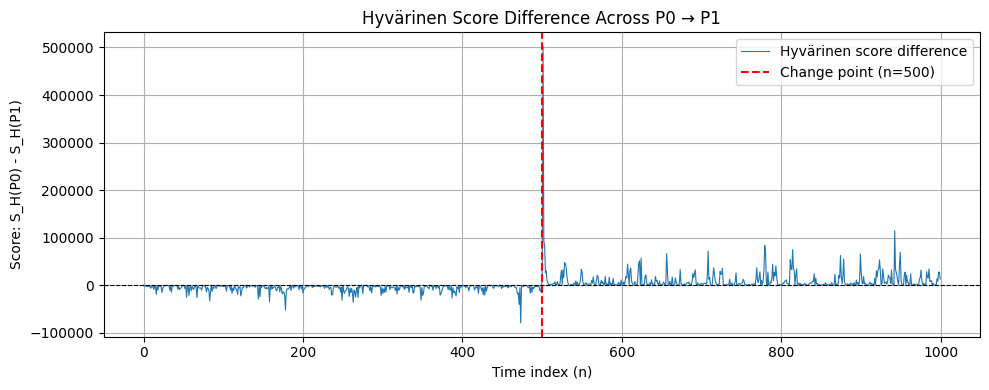

[P0 region] Mean: -5766.2646, Std: 21379.4531
[P1 region] Mean: 10789.9014, Std: nan


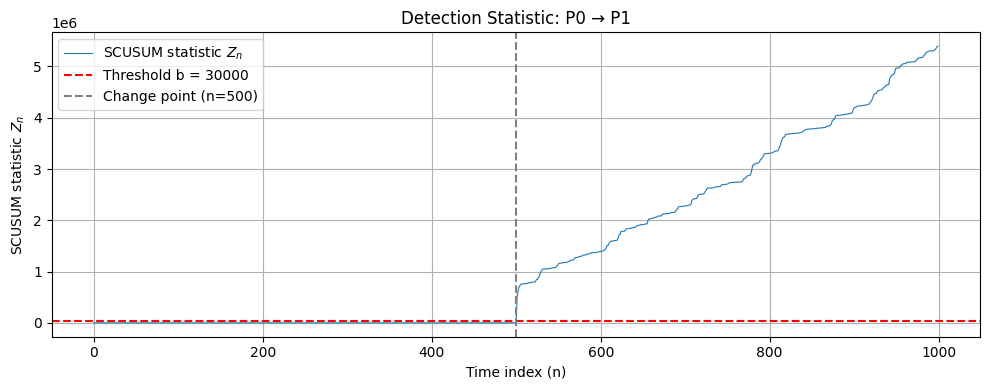

Change detected at n = 501 (threshold b = 30000), delay = 1


In [17]:
hidden_dim = 128
num_layers = 4

# Load hybrid path
X = torch.load(hybrid_path).float().to(device)  # shape (2001, d)
x_pairs = X[:-1]  # (2000, d)
y_pairs = X[1:]   # (2000, d)

# Load models
# Automatically locate model files
P0_model_pth = glob.glob(os.path.join(DATA_DIR, "P_0_128_4_*.pth"))[0]
P1_model_pth = glob.glob(os.path.join(DATA_DIR, "P_1_128_4_*.pth"))[0]

d = X.shape[1]
model_P0 = ConditionalScoreNet(d, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P1 = ConditionalScoreNet(d, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P0.load_state_dict(torch.load(P0_model_pth, map_location=device))
model_P1.load_state_dict(torch.load(P1_model_pth, map_location=device))
model_P0.eval()
model_P1.eval()

M = 1e9  # Truncation level

with torch.no_grad():
    score_p0 = compute_hyvarinen_score(model_P0, x_pairs, y_pairs)
    score_p1 = compute_hyvarinen_score(model_P1, x_pairs, y_pairs)

    # Difference and truncation
    diff_score = score_p0 - score_p1
    diff_score = torch.clamp(diff_score, min=-M, max=M)
    diff_score = diff_score.cpu().numpy()  # shape (2000,)


# Save score difference
out_path = os.path.join(DATA_DIR, "hybrid_score_difference.pt")
torch.save(torch.tensor(diff_score), out_path)
print("Saved score difference to:", out_path)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(diff_score, label="Hyvärinen score difference", lw=0.8)
plt.axvline(500, color="red", linestyle="--", label="Change point (n=500)")
plt.axhline(0, color="black", linestyle="--", lw=0.8)
plt.xlabel("Time index (n)")
plt.ylabel("Score: S_H(P0) - S_H(P1)")
plt.title("Hyvärinen Score Difference Across P0 → P1")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(os.path.join(DATA_DIR, "hybrid_score_difference_plot.pdf"))
plt.show()

# Summary statistics
print(f"[P0 region] Mean: {diff_score[:500].mean():.4f}, Std: {diff_score[:1000].std():.4f}")
print(f"[P1 region] Mean: {diff_score[500:].mean():.4f}, Std: {diff_score[1000:].std():.4f}")

b = 30000
Z = 0.0
T0 =NUM_PAIRS
Z_list = []  # store Z values over time
stopping_time = None

for n in range(len(diff_score)):
    s_n = np.clip(diff_score[n], -M, M)
    Z = max(0.0, Z + s_n)
    Z_list.append(Z)

    if stopping_time is None and Z >= b:
        stopping_time = n  # record first threshold crossing

# Plot SCUSUM statistic Z_n
plt.figure(figsize=(10, 4))
plt.plot(Z_list, label="SCUSUM statistic $Z_n$", lw=0.8)
plt.axhline(b, color="red", linestyle="--", label=f"Threshold b = {b}")
plt.axvline(T0, color="gray", linestyle="--", label=f"Change point (n={T0})")
plt.xlabel("Time index (n)")
plt.ylabel("SCUSUM statistic $Z_n$")
plt.title(f"Detection Statistic: P0 → P1")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(os.path.join(save_dir, "Z_plot_P0_to_P1.pdf"))
plt.show()


if stopping_time is not None:
    print(f"Change detected at n = {stopping_time} (threshold b = {b}), delay = {stopping_time - T0}")
else:
    print(f"No change detected (Z_n never crossed b = {b})")
